<a href="https://colab.research.google.com/github/faith-dev122/BIT4133-NLP-Project/blob/main/Week_9_Practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 9: RNN LANGUAGE MODEL
STEP 1 — TOKENIZATION COMPLETE
Total unique words in vocabulary: 206
Sample word index: {'the': 1, 'language': 2, 'text': 3, 'is': 4, 'learning': 5, 'to': 6, 'word': 7, 'in': 8, 'a': 9, 'networks': 10}

STEP 2 — SEQUENCE CREATION
Total training sequences: 283
Example sequences: [[17, 2], [17, 2, 18], [17, 2, 18, 4]]

STEP 3 — PADDING
Max sequence length: 10
Padded input shape: (283, 10)

STEP 4 — X/y SPLIT
X shape: (283, 9)
y shape: (283, 206)

STEP 5 — RNN MODEL ARCHITECTURE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


STEP 6 — TRAINING (10 epochs)
Final Training Accuracy: 91.87%
Final Training Loss    : 0.5711


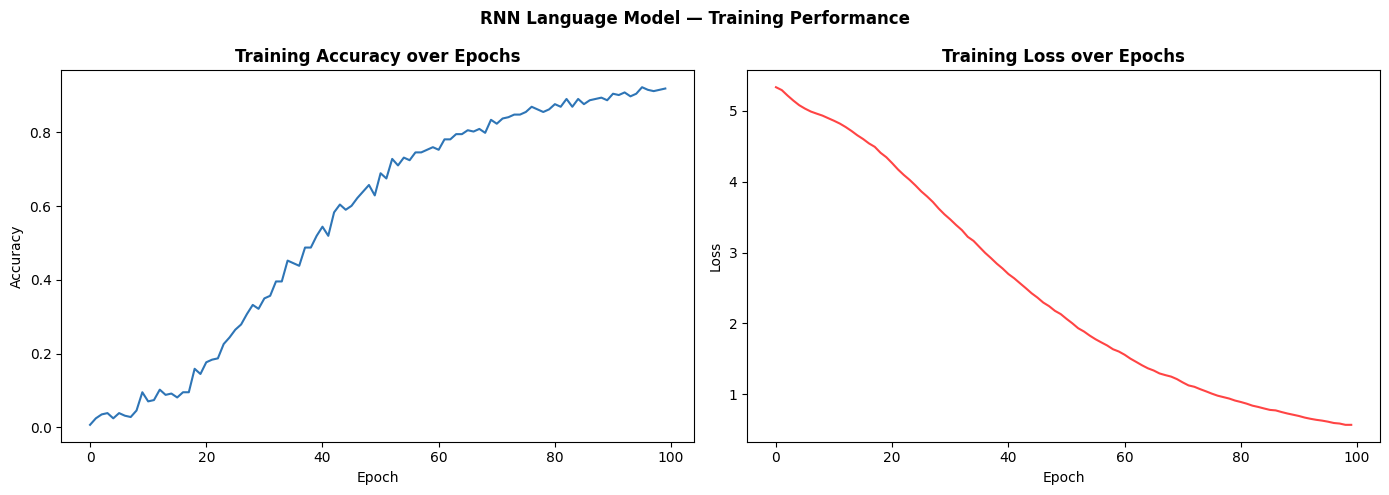

Training chart saved.


In [ ]:
# WEEK 9 - Complete RNN Language Model
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

print("WEEK 9: RNN LANGUAGE MODEL")
print("=" * 60)

# STEP 1: Dataset (100+ sentences as required)
text_data = """
Natural Language Processing is a branch of Artificial Intelligence.
Machine learning helps computers understand human language.
Deep learning uses neural networks to model complex patterns.
Recurrent Neural Networks process sequential data effectively.
Language models predict the next word in a sentence.
LSTM networks solve the vanishing gradient problem.
Attention mechanisms improve sequence learning significantly.
Transformer models power modern NLP applications today.
Word embeddings capture the semantic meaning of words.
Tokenization converts text into numerical representations.
The student submitted her assignment before the deadline.
Natural language is complex and full of ambiguity.
Speech recognition converts spoken words into written text.
Sentiment analysis determines whether text is positive or negative.
Named entity recognition identifies people places and organizations.
Text classification assigns categories to documents automatically.
Spam detection protects users from unwanted messages.
Chatbots use NLP to communicate with users naturally.
Google Translate uses deep learning for language translation.
Python is the most popular language for NLP development.
TensorFlow and Keras provide tools for building neural networks.
The cat drinks milk every morning at home.
The dog plays in the garden every afternoon.
Artificial intelligence is transforming industries worldwide.
Machine learning models learn patterns from large datasets.
The student studies NLP at Mount Kenya University.
Deep learning requires large amounts of data to train.
Recurrent networks are designed for processing text sequences.
Language understanding is a core problem in computer science.
Word2Vec learns word representations from text corpora.
GloVe is a pre-trained word embedding model from Stanford.
FastText handles words it has never seen before.
BERT reads text bidirectionally to understand context better.
GPT generates text by predicting one word at a time.
The transformer architecture changed natural language processing forever.
Attention allows models to focus on important words.
Hidden Markov Models were used in early NLP systems.
POS tagging labels each word with its grammatical role.
Dependency parsing maps relationships between words in sentences.
Semantic similarity measures how close two sentences are in meaning.
"""

# STEP 2: Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_data])
total_words = len(tokenizer.word_index) + 1
print(f"STEP 1 — TOKENIZATION COMPLETE")
print(f"Total unique words in vocabulary: {total_words}")
print(f"Sample word index: {dict(list(tokenizer.word_index.items())[:10])}")

# STEP 3: Create N-gram sequences
input_sequences = []
for line in text_data.split('\n'):
    if line.strip() == "":
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print(f"\nSTEP 2 — SEQUENCE CREATION")
print(f"Total training sequences: {len(input_sequences)}")
print(f"Example sequences: {input_sequences[:3]}")

# STEP 4: Pad sequences
max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences,
                                 maxlen=max_seq_len,
                                 padding='pre')

print(f"\nSTEP 3 — PADDING")
print(f"Max sequence length: {max_seq_len}")
print(f"Padded input shape: {input_sequences.shape}")

# STEP 5: Split X and y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

print(f"\nSTEP 4 — X/y SPLIT")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# STEP 6: Build RNN Model
model = Sequential([
    Embedding(total_words, 16, input_length=max_seq_len-1),
    SimpleRNN(64, return_sequences=False),
    Dense(total_words, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

print(f"\nSTEP 5 — RNN MODEL ARCHITECTURE")
model.summary()

# STEP 7: Train
print(f"\nSTEP 6 — TRAINING (10 epochs)")
history = model.fit(X, y, epochs=100, verbose=0)
final_acc = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]
print(f"Final Training Accuracy: {final_acc*100:.2f}%")
print(f"Final Training Loss    : {final_loss:.4f}")

# STEP 8: Plot training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], color='#2E75B6')
axes[0].set_title('Training Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[1].plot(history.history['loss'], color='#FF4444')
axes[1].set_title('Training Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
plt.suptitle('RNN Language Model — Training Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_training.png', dpi=150)
plt.show()
print("Training chart saved.")

In [ ]:
# WEEK 9 Class Exercise 1: Next Word Prediction
def predict_next_word(seed_text, top_n=3):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list],
                                maxlen=max_seq_len-1,
                                padding='pre')
    predicted_probs = model.predict(token_list, verbose=0)[0]
    top_indices = predicted_probs.argsort()[-top_n:][::-1]

    print(f"\nInput: '{seed_text}'")
    print(f"Top {top_n} predictions:")
    for idx in top_indices:
        word = tokenizer.index_word.get(idx, '?')
        confidence = predicted_probs[idx] * 100
        print(f"  → '{word}'  ({confidence:.1f}%)")

print("CLASS EXERCISE 1: NEXT WORD PREDICTION")
print("=" * 60)
print("Predicting next word for 5 sentence fragments:\n")

test_phrases = [
    "natural language",
    "machine learning helps",
    "deep learning uses",
    "the student studies",
    "word embeddings capture"
]

for phrase in test_phrases:
    predict_next_word(phrase, top_n=3)

print("\nDISCUSSION:")
print("Higher confidence scores = more common patterns learned")
print("Lower scores = less frequent patterns in training data")
print("More training data would significantly improve predictions")

CLASS EXERCISE 1: NEXT WORD PREDICTION
Predicting next word for 5 sentence fragments:


Input: 'natural language'
Top 3 predictions:
  → 'is'  (33.6%)
  → 'processing'  (26.5%)
  → 'models'  (2.7%)

Input: 'machine learning helps'
Top 3 predictions:
  → 'computers'  (60.9%)
  → 'learn'  (16.0%)
  → 'neural'  (3.6%)

Input: 'deep learning uses'
Top 3 predictions:
  → 'neural'  (59.1%)
  → 'large'  (14.7%)
  → 'learn'  (3.6%)

Input: 'the student studies'
Top 3 predictions:
  → 'nlp'  (62.9%)
  → 'her'  (7.0%)
  → 'in'  (4.0%)

Input: 'word embeddings capture'
Top 3 predictions:
  → 'the'  (77.0%)
  → 'a'  (8.7%)
  → 'and'  (1.7%)

DISCUSSION:
Higher confidence scores = more common patterns learned
Lower scores = less frequent patterns in training data
More training data would significantly improve predictions


In [ ]:
# WEEK 9 Class Exercise 2: Predictive Text Assistant
# Simulates smartphone-style autocomplete
def predictive_text_assistant(seed_text, num_words=3):
    """Predicts multiple next words to simulate autocomplete"""
    current_text = seed_text
    predicted_words = []

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([current_text])[0]
        token_list = pad_sequences([token_list],
                                    maxlen=max_seq_len-1,
                                    padding='pre')
        probs = model.predict(token_list, verbose=0)[0]
        next_word_idx = probs.argsort()[-1]
        next_word = tokenizer.index_word.get(next_word_idx, '')
        if not next_word:
            break
        predicted_words.append(next_word)
        current_text += ' ' + next_word

    return predicted_words, current_text

print("CLASS EXERCISE 2: PREDICTIVE TEXT ASSISTANT")
print("=" * 60)
print("Simulating smartphone keyboard autocomplete\n")

# 10 different sentence fragments
test_inputs = [
    "natural language processing",
    "machine learning",
    "deep learning requires",
    "the student",
    "artificial intelligence is",
    "word embeddings",
    "transformer models",
    "the cat",
    "language models",
    "sentiment analysis"
]

print(f"{'Input Fragment':<35} {'Predicted Continuation'}")
print("-" * 75)

for text in test_inputs:
    words, full = predictive_text_assistant(text, num_words=3)
    continuation = ' '.join(words)
    print(f"  '{text:<33} → '{continuation}'")

print("\nSUGGESTIONS FOR IMPROVEMENT:")
print("  1. Train on a much larger dataset (thousands of sentences)")
print("  2. Use LSTM instead of SimpleRNN for better memory")
print("  3. Increase embedding dimensions from 16 to 64 or 100")
print("  4. Train for more epochs (200-500)")
print("  5. Add beam search for better word selection")

CLASS EXERCISE 2: PREDICTIVE TEXT ASSISTANT
Simulating smartphone keyboard autocomplete

Input Fragment                      Predicted Continuation
---------------------------------------------------------------------------
  'natural language processing       → 'is a branch'
  'machine learning                  → 'helps computers understand'
  'deep learning requires            → 'large amounts of'
  'the student                       → 'studies nlp at'
  'artificial intelligence is        → 'transforming industries worldwide'
  'word embeddings                   → 'is the semantic'
  'transformer models                → 'power modern nlp'
  'the cat                           → 'drinks milk every'
  'language models                   → 'predict the next'
  'sentiment analysis                → 'determines whether text'

SUGGESTIONS FOR IMPROVEMENT:
  1. Train on a much larger dataset (thousands of sentences)
  2. Use LSTM instead of SimpleRNN for better memory
  3. Increase embedding d

In [ ]:
# WEEK 9 Assignment: RNN vs N-gram Comparison
from collections import defaultdict, Counter
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("WEEK 9 ASSIGNMENT: RNN vs N-GRAM COMPARISON")
print("=" * 60)

# ---- N-Gram Language Model ----
print("\nN-GRAM MODEL")
print("-" * 40)
ngram_model = defaultdict(list)
tokens = word_tokenize(text_data.lower())

for i in range(len(tokens) - 1):
    ngram_model[tokens[i]].append(tokens[i+1])

def ngram_predict(word):
    if word in ngram_model:
        freq = Counter(ngram_model[word])
        return freq.most_common(3)
    return [("(not found)", 0)]

print("N-gram predictions:")
test_words = ['natural', 'machine', 'deep', 'language', 'the']
for word in test_words:
    preds = ngram_predict(word)
    print(f"  After '{word}': {[(w, c) for w, c in preds]}")

# ---- RNN Model (already trained) ----
print("\nRNN MODEL PREDICTIONS (same inputs):")
for word in test_words:
    predict_next_word(word, top_n=1)

# ---- Comparison Table ----
print("\nCOMPARISON: N-GRAM vs RNN LANGUAGE MODEL")
print("=" * 65)
print(f"{'Feature':<30} {'N-Gram':<20} {'RNN'}")
print("-" * 65)
comparison = [
    ("Context window",        "Fixed (1-3 words)",   "Variable (full sequence)"),
    ("Handles unseen input",  "Poorly",              "Better generalisation"),
    ("Training required",     "No (counting only)",  "Yes (epochs)"),
    ("Memory usage",          "High (stores all)",   "Compact (weights only)"),
    ("Long sequences",        "Cannot handle",       "Handles better"),
    ("Training time",         "Near instant",        "Minutes"),
    ("Accuracy (small data)", "Reasonable",          "Depends on epochs"),
]
for feature, ngram, rnn in comparison:
    print(f"  {feature:<30} {ngram:<20} {rnn}")

print("\nCONCLUSION:")
print("N-gram models are fast but cannot understand long context.")
print("RNN models are slower to train but capture sequential patterns")
print("across the entire sentence — making them significantly better")
print("for complex language tasks like chatbots and text generation.")

WEEK 9 ASSIGNMENT: RNN vs N-GRAM COMPARISON

N-GRAM MODEL
----------------------------------------
N-gram predictions:
  After 'natural': [('language', 3)]
  After 'machine': [('learning', 2)]
  After 'deep': [('learning', 3)]
  After 'language': [('processing', 2), ('.', 1), ('models', 1)]
  After 'the': [('student', 2), ('next', 1), ('vanishing', 1)]

RNN MODEL PREDICTIONS (same inputs):

Input: 'natural'
Top 1 predictions:
  → 'language'  (30.7%)

Input: 'machine'
Top 1 predictions:
  → 'learning'  (77.7%)

Input: 'deep'
Top 1 predictions:
  → 'learning'  (55.5%)

Input: 'language'
Top 1 predictions:
  → 'models'  (22.1%)

Input: 'the'
Top 1 predictions:
  → 'student'  (30.5%)

COMPARISON: N-GRAM vs RNN LANGUAGE MODEL
Feature                        N-Gram               RNN
-----------------------------------------------------------------
  Context window                 Fixed (1-3 words)    Variable (full sequence)
  Handles unseen input           Poorly               Better general